# Notebook 05 – CNN Demand Prediction

## Objective

Train a Convolutional Neural Network (CNN) to predict the
ride-hailing demand for the next 30-minute interval.

The model uses the multi-channel spatial tensors generated
in Notebook 04 as input and predicts the future demand map.

### Inputs

- X_train.npy
- y_train.npy
- X_test.npy
- y_test.npy
- metadata.pkl

### Outputs

- Trained CNN model
- Training history
- Predicted demand maps
- Performance metrics (RMSE, MAE and MAPE)

# =====================================================
# STAGE 2 : IMPORT LIBRARIES
# =====================================================

## Objective

Import all libraries required for building, training,
and evaluating the convolutional neural network.

In [ ]:
# =====================================================
# IMPORT LIBRARIES
# =====================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv2D,
    Input
)

from tensorflow.keras.optimizers import Adam

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

from google.colab import drive
import os
import shutil
import time # Added for small delays

mountpoint = '/content/drive'

# --- Step 1: Attempt to unmount if already mounted ---
if os.path.ismount(mountpoint):
    print(f"Detected {mountpoint} is already mounted. Attempting to unmount...")
    try:
        !fusermount -uz {mountpoint}
        print(f"Successfully unmounted {mountpoint} (if it was a fusermount). This clears any temporary files on the Colab VM's local filesystem at this location, not your actual Google Drive files.")
    except Exception as e:
        print(f"Error during fusermount unmount attempt: {e}. Proceeding with directory cleanup.")
else:
    print(f"{mountpoint} is not currently an active mount point.")

# Add a small delay to ensure unmount operations fully propagate
time.sleep(1)

# --- Step 2: Forcibly remove and recreate the mountpoint directory to ensure it's empty ---
print(f"Ensuring {mountpoint} is a fresh, empty directory before mounting...")
if os.path.exists(mountpoint):
    try:
        shutil.rmtree(mountpoint)
        print(f"Successfully removed existing {mountpoint} directory and its contents from the Colab VM's local filesystem.")
        time.sleep(0.5) # Give a moment for filesystem to register removal
    except OSError as e:
        print(f"Error removing {mountpoint}: {e}. This indicates a persistent lock or permission issue.")
        print("Attempting to create directory, but mount might still fail if directory is locked.")
else:
    print(f"Directory {mountpoint} does not exist on the Colab VM, creating it.")

# Always create the mountpoint directory to ensure it's an empty, clean target
# This ensures it's empty right before drive.mount is called
os.makedirs(mountpoint, exist_ok=True)
print(f"Created/ensured empty mountpoint directory: {mountpoint} on the Colab VM.")
time.sleep(0.5) # Another small delay

# --- Step 3: Attempt to mount Google Drive ---
print("Attempting to mount Google Drive...")
try:
    drive.mount(mountpoint, force_remount=True)
    print("Google Drive mount attempt complete.")
    if os.path.ismount(mountpoint):
        print("Google Drive successfully mounted! Your files should now be accessible via this path.")
    else:
        print("Google Drive did not mount successfully, despite no immediate exception.")
except Exception as e:
    print(f"An error occurred during drive.mount: {e}")
    print("Please check your permissions, restart the runtime, or ensure no other process is using the mountpoint.")

from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras import layers, models

Detected /content/drive is already mounted. Attempting to unmount...
Successfully unmounted /content/drive (if it was a fusermount). This clears any temporary files on the Colab VM's local filesystem at this location, not your actual Google Drive files.
Ensuring /content/drive is a fresh, empty directory before mounting...
Directory /content/drive does not exist on the Colab VM, creating it.
Created/ensured empty mountpoint directory: /content/drive on the Colab VM.
Attempting to mount Google Drive...
Mounted at /content/drive
Google Drive mount attempt complete.
Google Drive successfully mounted! Your files should now be accessible via this path.


# =====================================================
# STAGE 4 : PROJECT PATHS
# =====================================================

## Objective

Define the project directory structure and locate the
CNN datasets generated in Notebook 04.

In [ ]:
# =====================================================
# PROJECT PATHS
# =====================================================

PROJECT_ROOT = Path("/content/drive/MyDrive/RideHailingPhD")

PROCESSED_DIR = PROJECT_ROOT / "processed_data"

CNN_DIR = PROCESSED_DIR / "cnn"

MODEL_DIR = PROJECT_ROOT / "models"

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# =====================================================
# STAGE 5 : MODEL CONFIGURATION
# =====================================================

## Objective

Define the CNN architecture and training parameters.

Keeping these values in one location makes the notebook
easy to modify and reproduce.

In [ ]:
# =====================================================
# MODEL CONFIGURATION
# =====================================================

FILTERS = [32, 64, 32]

KERNEL_SIZE = (3, 3)

LEARNING_RATE = 0.001

BATCH_SIZE = 32

EPOCHS = 50

VALIDATION_SPLIT = 0.20

# =====================================================
# STAGE 6 : LOAD CNN DATASET
# =====================================================

## Objective

Load the training and testing datasets generated
in Notebook 04.

The datasets consist of seven-channel spatial tensors
representing the city at each 30-minute interval.

In [ ]:
# =====================================================
# LOAD CNN DATASET
# =====================================================

X_train = np.load(
    CNN_DIR / "X_train.npy"
)

y_train = np.load(
    CNN_DIR / "y_train.npy"
)

X_test = np.load(
    CNN_DIR / "X_test.npy"
)

y_test = np.load(
    CNN_DIR / "y_test.npy"
)

with open(
    CNN_DIR / "metadata.pkl",
    "rb"
) as f:

    metadata = pickle.load(f)

print(f"Training Samples : {len(X_train):,}")
print(f"Testing Samples  : {len(X_test):,}")

print()

print("Input Shape")

print(X_train.shape)

print()

print("Target Shape")

print(y_train.shape)

Training Samples : 1,189
Testing Samples  : 298

Input Shape
(1189, 7, 51, 52)

Target Shape
(1189, 1, 51, 52)


# =====================================================
# STAGE 6A : DATASET CONFIGURATION
# =====================================================

## Objective

Extract the dataset dimensions and channel information
from the metadata file created in Notebook 04.

These values are used throughout the notebook to avoid
hardcoding the input dimensions.

In [ ]:
# =====================================================
# DATASET CONFIGURATION
# =====================================================

GRID_ROWS = metadata["rows"]
GRID_COLS = metadata["cols"]
NUM_CHANNELS = len(metadata["channels"])

print("=" * 60)
print("DATASET CONFIGURATION")
print("=" * 60)

print(f"Grid Rows     : {GRID_ROWS}")
print(f"Grid Columns  : {GRID_COLS}")
print(f"Channels      : {NUM_CHANNELS}")

print()

print("Input Shape")

print(f"({GRID_ROWS}, {GRID_COLS}, {NUM_CHANNELS})")

DATASET CONFIGURATION
Grid Rows     : 51
Grid Columns  : 52
Channels      : 7

Input Shape
(51, 52, 7)


# =====================================================
# STAGE 7 : NORMALIZE INPUT FEATURES
# =====================================================

## Objective

Normalize each input channel independently using the
statistics computed from the training dataset.

The same normalization parameters are then applied to
the testing dataset to prevent data leakage.

In [ ]:
# =====================================================
# COMPUTE CHANNEL STATISTICS
# =====================================================

channel_means = []
channel_stds = []

for channel in range(X_train.shape[1]):

    mean = X_train[:, channel].mean()
    std = X_train[:, channel].std()

    # Prevent division by zero
    if std == 0:
        std = 1.0

    channel_means.append(mean)
    channel_stds.append(std)

channel_means = np.array(channel_means, dtype=np.float32)
channel_stds = np.array(channel_stds, dtype=np.float32)

print("=" * 60)
print("CHANNEL STATISTICS")
print("=" * 60)

for i, feature in enumerate(metadata["channels"]):

    print(
        f"{feature:20s}"
        f" Mean = {channel_means[i]:8.3f}"
        f" Std = {channel_stds[i]:8.3f}"
    )

CHANNEL STATISTICS
HistoricalDemand     Mean =    0.627 Std =    6.059
Temperature          Mean =    0.775 Std =    3.436
WindSpeed            Mean =    5.686 Std =    7.962
WeatherCode          Mean =    1.476 Std =    2.612
DayOfWeek            Mean =    1.470 Std =    2.077
Hour                 Mean =    5.221 Std =    7.354
Period               Mean =   10.670 Std =   14.905


In [ ]:
# =====================================================
# NORMALIZE DATA
# =====================================================

X_train_norm = X_train.copy()
X_test_norm = X_test.copy()

for channel in range(X_train.shape[1]):

    X_train_norm[:, channel] = (
        X_train[:, channel] - channel_means[channel]
    ) / channel_stds[channel]

    X_test_norm[:, channel] = (
        X_test[:, channel] - channel_means[channel]
    ) / channel_stds[channel]

print("Input normalization completed.")

Input normalization completed.


In [ ]:
# =====================================================
# VALIDATE NORMALIZATION
# =====================================================

print("=" * 60)
print("NORMALIZED CHANNEL STATISTICS")
print("=" * 60)

for i, feature in enumerate(metadata["channels"]):

    values = X_train_norm[:, i]

    print(
        f"{feature:20s}"
        f" Mean = {values.mean():8.3f}"
        f" Std = {values.std():8.3f}"
    )

NORMALIZED CHANNEL STATISTICS
HistoricalDemand     Mean =   -0.000 Std =    1.000
Temperature          Mean =    0.000 Std =    1.000
WindSpeed            Mean =    0.000 Std =    1.000
WeatherCode          Mean =    0.000 Std =    1.000
DayOfWeek            Mean =   -0.000 Std =    1.000
Hour                 Mean =    0.000 Std =    1.000
Period               Mean =   -0.000 Std =    1.000


# =====================================================
# SAVE NORMALIZATION PARAMETERS
# =====================================================

## Objective

Save the normalization parameters computed from the
training dataset.

These parameters will be reused whenever the trained
CNN is applied to new demand data.

In [ ]:
# =====================================================
# SAVE NORMALIZATION PARAMETERS
# =====================================================

normalization = {
    "means": channel_means,
    "stds": channel_stds,
    "channels": metadata["channels"]
}

with open(
    MODEL_DIR / "normalization.pkl",
    "wb"
) as f:

    pickle.dump(
        normalization,
        f
    )

print("Normalization parameters saved.")

Normalization parameters saved.


# =====================================================
# STAGE 8 : BUILD CNN MODEL
# =====================================================

## Objective

Construct the Convolutional Neural Network (CNN) used to
predict the ride-hailing demand for the next 30-minute interval.

The model receives a seven-channel spatial tensor as input
and predicts the future demand map while preserving the
spatial dimensions of the city grid.

Unlike image classification networks, no pooling or fully
connected layers are used because the objective is to
predict demand for every grid cell.

## Convert Tensor Layout

TensorFlow expects image data in the format:

(Samples, Height, Width, Channels)

whereas the tensors generated in Notebook 04 are stored as:

(Samples, Channels, Height, Width)

This stage converts the tensors into the format required
by TensorFlow.

In [ ]:
# =====================================================
# CONVERT TO TENSORFLOW FORMAT
# =====================================================

X_train_tf = np.transpose(
    X_train_norm,
    (0, 2, 3, 1)
)

X_test_tf = np.transpose(
    X_test_norm,
    (0, 2, 3, 1)
)

y_train_tf = np.transpose(
    y_train,
    (0, 2, 3, 1)
)

y_test_tf = np.transpose(
    y_test,
    (0, 2, 3, 1)
)

print("=" * 60)
print("TENSORFLOW DATASET")
print("=" * 60)

print("Training Input :", X_train_tf.shape)
print("Training Target:", y_train_tf.shape)

print()

print("Testing Input  :", X_test_tf.shape)
print("Testing Target :", y_test_tf.shape)

TENSORFLOW DATASET
Training Input : (1189, 51, 52, 7)
Training Target: (1189, 51, 52, 1)

Testing Input  : (298, 51, 52, 7)
Testing Target : (298, 51, 52, 1)


## CNN Architecture

The CNN consists of four convolutional layers.

The first three layers learn increasingly complex spatial
patterns from the input feature maps.

The final convolution layer produces one demand prediction
for every grid cell.

The spatial dimensions remain unchanged throughout the
network by using **padding='same'**.

In [ ]:
# =====================================================
# BUILD CNN MODEL
# =====================================================

from tensorflow.keras.layers import Input, Conv2D
from tensorflow.keras.models import Model

inputs = Input(
    shape=(
        GRID_ROWS,
        GRID_COLS,
        NUM_CHANNELS
    ),
    name="InputLayer"
)

# -----------------------------------------------------
# Convolution Layer 1
# -----------------------------------------------------

x = Conv2D(
    filters=FILTERS[0],
    kernel_size=KERNEL_SIZE,
    padding="same",
    activation="relu",
    name="Conv1"
)(inputs)

# -----------------------------------------------------
# Convolution Layer 2
# -----------------------------------------------------

x = Conv2D(
    filters=FILTERS[1],
    kernel_size=KERNEL_SIZE,
    padding="same",
    activation="relu",
    name="Conv2"
)(x)

# -----------------------------------------------------
# Convolution Layer 3
# -----------------------------------------------------

x = Conv2D(
    filters=FILTERS[2],
    kernel_size=KERNEL_SIZE,
    padding="same",
    activation="relu",
    name="Conv3"
)(x)

# -----------------------------------------------------
# Output Layer
# -----------------------------------------------------

outputs = Conv2D(
    filters=1,
    kernel_size=(1, 1),
    padding="same",
    activation="linear",
    name="OutputLayer"
)(x)

model = Model(
    inputs=inputs,
    outputs=outputs,
    name="DemandPredictionCNN"
)

## Model Compilation

The CNN is trained as a regression model.

Loss Function:
- Mean Squared Error (MSE)

Optimizer:
- Adam

Metric:
- Mean Absolute Error (MAE)

In [ ]:
# =====================================================
# COMPILE MODEL
# =====================================================

optimizer = Adam(
    learning_rate=LEARNING_RATE
)

model.compile(
    optimizer=optimizer,
    loss="mse",
    metrics=["mae"]
)

print("Model compiled successfully.")

Model compiled successfully.


## Model Summary

Display the complete CNN architecture, including the
output shape of every layer and the number of trainable
parameters.

In [ ]:
# =====================================================
# MODEL SUMMARY
# =====================================================

model.summary()

Model: "DemandPredictionCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ InputLayer (InputLayer)         │ (None, 51, 52, 7)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv1 (Conv2D)                  │ (None, 51, 52, 32)     │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2 (Conv2D)                  │ (None, 51, 52, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv3 (Conv2D)                  │ (None, 51, 52, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ OutputLayer (Conv2D)            │ (None, 51, 52, 1)      │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,041 (152.50 KB)

 Trainable params: 39,041 (152.50 KB)

 Non-trainable params: 0 (0.00 B)

# =====================================================
# STAGE 9 : TRAIN CNN MODEL
# =====================================================

## Objective

Train the CNN using the normalized training dataset.

During training, the model learns the relationship
between historical demand, weather, temporal features,
and future ride-hailing demand.

Early stopping is used to prevent overfitting by
terminating training when the validation loss stops
improving.

In [ ]:
# =====================================================
# TRAINING CALLBACKS
# =====================================================

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(

    monitor="val_loss",

    patience=5,

    restore_best_weights=True,

    verbose=1
)

In [ ]:
# =====================================================
# TRAIN CNN
# =====================================================

history = model.fit(

    X_train_tf,

    y_train_tf,

    validation_split=VALIDATION_SPLIT,

    epochs=EPOCHS,

    batch_size=BATCH_SIZE,

    callbacks=[early_stop],

    shuffle=True,

    verbose=1
)

Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - loss: 35.2003 - mae: 1.2419 - val_loss: 15.0371 - val_mae: 0.9335
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 22.4878 - mae: 0.8341 - val_loss: 14.7469 - val_mae: 1.0107
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 21.0317 - mae: 0.7702 - val_loss: 11.5457 - val_mae: 0.8687
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 19.8683 - mae: 0.7528 - val_loss: 9.7748 - val_mae: 0.7020
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 19.3509 - mae: 0.7627 - val_loss: 8.5274 - val_mae: 0.6350
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 18.8970 - mae: 0.7575 - val_loss: 8.5653 - val_mae: 0.5921
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 18.5696 - mae: 0.7604 - val_loss: 9.5411 - val_mae: 0.7294
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 18.5098 - mae: 0.7439 - val_loss: 8.9476 - val_mae: 0.6719
Epoch 9/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - 

In [ ]:
# =====================================================
# TRAINING SUMMARY
# =====================================================

best_epoch = np.argmin(history.history["val_loss"]) + 1
best_val_loss = np.min(history.history["val_loss"])

print("=" * 60)
print("TRAINING COMPLETED")
print("=" * 60)

print(f"Epochs Trained       : {len(history.history['loss'])}")
print(f"Best Epoch           : {best_epoch}")

print()

print(f"Final Training Loss  : {history.history['loss'][-1]:.4f}")
print(f"Best Validation Loss : {best_val_loss:.4f}")

print()

print("CNN training completed successfully.")

TRAINING COMPLETED
Epochs Trained       : 10
Best Epoch           : 5

Final Training Loss  : 17.9419
Best Validation Loss : 8.5274

CNN training completed successfully.


# =====================================================
# STAGE 9A : TRAINING HISTORY
# =====================================================

## Objective

Visualize the training and validation loss throughout
the learning process.

The learning curves help identify convergence,
underfitting, and overfitting.

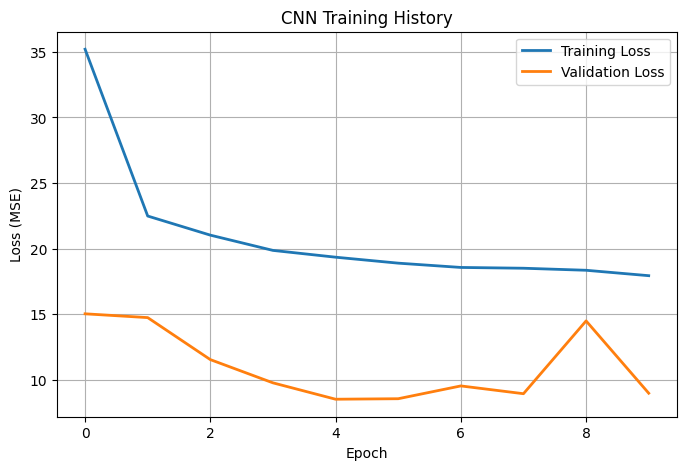

In [ ]:
# =====================================================
# PLOT TRAINING HISTORY
# =====================================================

plt.figure(figsize=(8,5))

plt.plot(
    history.history["loss"],
    label="Training Loss",
    linewidth=2
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss",
    linewidth=2
)

plt.xlabel("Epoch")

plt.ylabel("Loss (MSE)")

plt.title("CNN Training History")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
print(X_train_tf.shape)
print(X_test_tf.shape)

(1189, 51, 52, 7)
(298, 51, 52, 7)


# =====================================================
# STAGE 10 : MODEL EVALUATION
# =====================================================

## Objective

Evaluate the trained CNN using the unseen testing dataset.

The model predicts the demand map for every 30-minute
interval and is evaluated using three regression metrics:

- Root Mean Squared Error (RMSE)
- Mean Absolute Error (MAE)
- Mean Absolute Percentage Error (MAPE)

In [ ]:
# =====================================================
# GENERATE PREDICTIONS
# =====================================================

y_pred = model.predict(
    X_test_tf,
    verbose=1
)

print("=" * 60)
print("PREDICTION SUMMARY")
print("=" * 60)

print(f"Prediction Shape : {y_pred.shape}")
print(f"Target Shape     : {y_test_tf.shape}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step
PREDICTION SUMMARY
Prediction Shape : (298, 51, 52, 1)
Target Shape     : (298, 51, 52, 1)


In [ ]:
# =====================================================
# PREPARE ARRAYS FOR EVALUATION
# =====================================================

y_true = y_test_tf.reshape(-1)

y_est = y_pred.reshape(-1)

print(f"Evaluation Samples : {len(y_true):,}")

Evaluation Samples : 790,296


In [ ]:
# =====================================================
# COMPUTE PERFORMANCE METRICS
# =====================================================

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error
)

rmse = np.sqrt(
    mean_squared_error(
        y_true,
        y_est
    )
)

mae = mean_absolute_error(
    y_true,
    y_est
)

# -----------------------------------------------------
# Avoid divide-by-zero for MAPE
# -----------------------------------------------------

mask = y_true > 0

mape = np.mean(
    np.abs(
        (y_true[mask] - y_est[mask]) /
        y_true[mask]
    )
) * 100

In [ ]:
# =====================================================
# MODEL PERFORMANCE
# =====================================================

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# -----------------------------------------------------
# Compute Metrics
# -----------------------------------------------------

rmse = np.sqrt(
    mean_squared_error(y_true, y_est)
)

mae = mean_absolute_error(
    y_true,
    y_est
)

mask = y_true > 0

mape = np.mean(
    np.abs(
        (y_true[mask] - y_est[mask]) /
        y_true[mask]
    )
) * 100

r2 = r2_score(
    y_true,
    y_est
)

# -----------------------------------------------------
# Results Table
# -----------------------------------------------------

results = pd.DataFrame({

    "Metric": [
        "RMSE",
        "MAE",
        "MAPE (%)",
        "R² Score"
    ],

    "Value": [
        rmse,
        mae,
        mape,
        r2
    ]

})

print("=" * 60)
print("CNN PERFORMANCE")
print("=" * 60)

display(results.round(4))

CNN PERFORMANCE


,Metric,Value
0,RMSE,2.6186
1,MAE,0.6359
2,MAPE (%),76.4488
3,R² Score,0.8964


In [ ]:
# =====================================================
# SAVE RESULTS
# =====================================================

results.to_csv(

    MODEL_DIR / "cnn_metrics.csv",

    index=False

)

np.save(

    MODEL_DIR / "cnn_predictions.npy",

    y_pred

)

model.save(

    MODEL_DIR / "cnn_model.keras"

)

with open(

    MODEL_DIR / "cnn_history.pkl",

    "wb"

) as f:

    pickle.dump(

        history.history,

        f

    )

print("Evaluation results saved.")

Evaluation results saved.


# =====================================================
# STAGE 11 : VISUALIZE PREDICTIONS
# =====================================================

## Objective

Compare the predicted demand map with the actual demand map
for selected testing time slots.

Visual inspection complements the numerical evaluation
metrics by highlighting where the CNN predicts demand
accurately and where larger errors occur.

In [ ]:
# =====================================================
# SELECT TEST SAMPLE
# =====================================================

sample = 0

actual = y_test_tf[sample, :, :, 0]

predicted = y_pred[sample, :, :, 0]

difference = predicted - actual

print("Sample Index :", sample)

Sample Index : 0


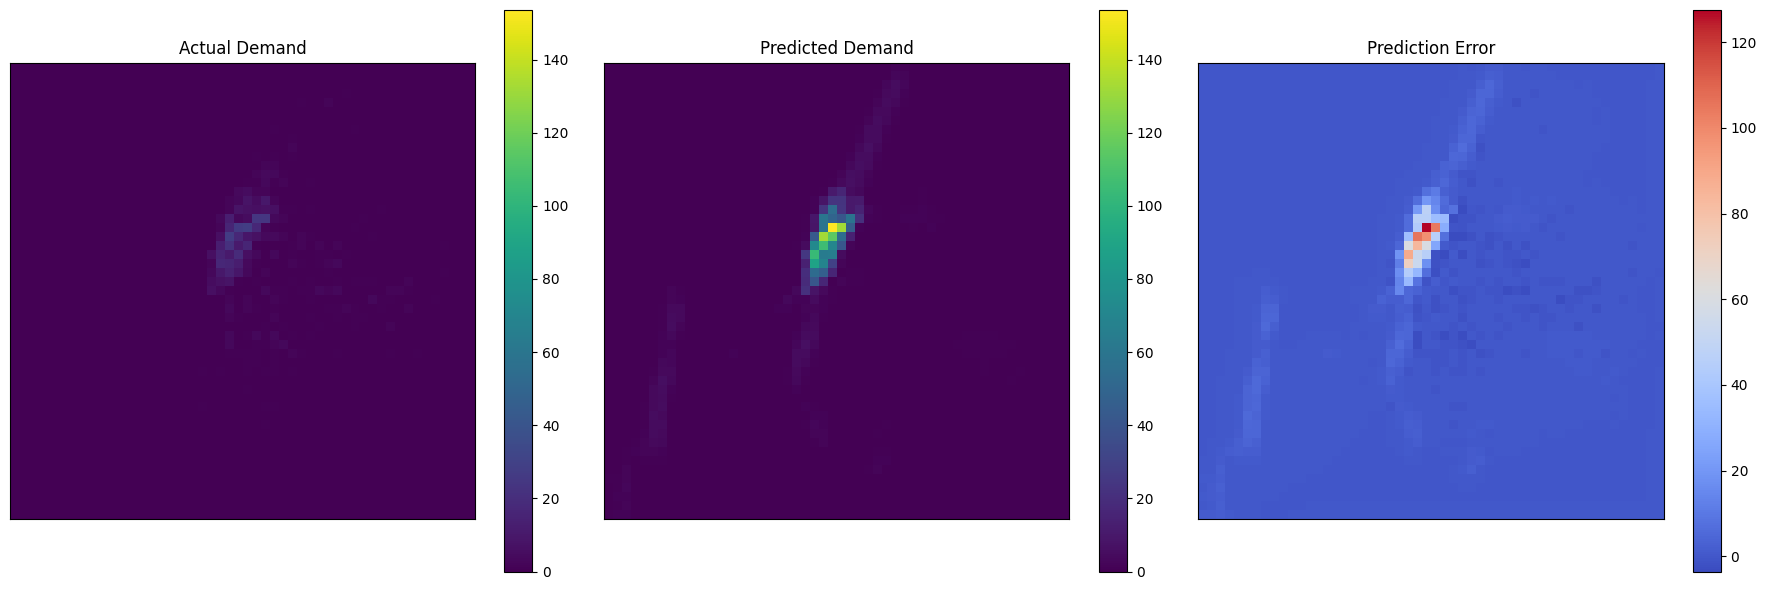

In [ ]:
# =====================================================
# VISUALIZE DEMAND MAPS
# =====================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18,6)
)

vmax = max(
    actual.max(),
    predicted.max()
)

# ----------------------------------------------------
# Actual Demand
# ----------------------------------------------------

im1 = axes[0].imshow(
    actual,
    cmap="viridis",
    vmin=0,
    vmax=vmax
)

axes[0].set_title("Actual Demand")

# ----------------------------------------------------
# Predicted Demand
# ----------------------------------------------------

im2 = axes[1].imshow(
    predicted,
    cmap="viridis",
    vmin=0,
    vmax=vmax
)

axes[1].set_title("Predicted Demand")

# ----------------------------------------------------
# Prediction Error
# ----------------------------------------------------

im3 = axes[2].imshow(
    difference,
    cmap="coolwarm"
)

axes[2].set_title("Prediction Error")

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

plt.colorbar(im1, ax=axes[0])

plt.colorbar(im2, ax=axes[1])

plt.colorbar(im3, ax=axes[2])

plt.tight_layout()

plt.show()

In [ ]:
# =====================================================
# TOTAL DEMAND COMPARISON
# =====================================================

print("=" * 60)
print("TOTAL DEMAND")
print("=" * 60)

print(f"Actual Demand    : {actual.sum():.0f}")

print(f"Predicted Demand : {predicted.sum():.0f}")

print(f"Difference       : {(predicted.sum()-actual.sum()):.0f}")

TOTAL DEMAND
Actual Demand    : 763
Predicted Demand : 2936
Difference       : 2173


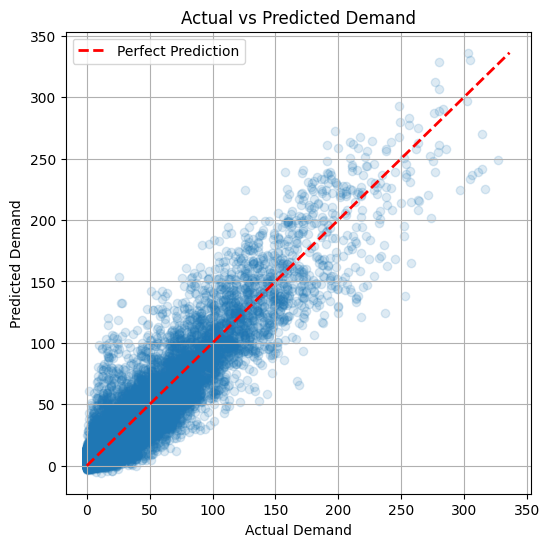

In [ ]:
# =====================================================
# ACTUAL VS PREDICTED SCATTER PLOT
# =====================================================
max_val = max(y_true.max(), y_pred.max())

plt.figure(figsize=(6,6))

plt.scatter(y_true, y_pred, alpha=0.15)

plt.plot(
    [0, max_val],
    [0, max_val],
    "r--",
    linewidth=2,
    label="Perfect Prediction"
)

plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")
plt.title("Actual vs Predicted Demand")

plt.legend()
plt.grid(True)

plt.show()

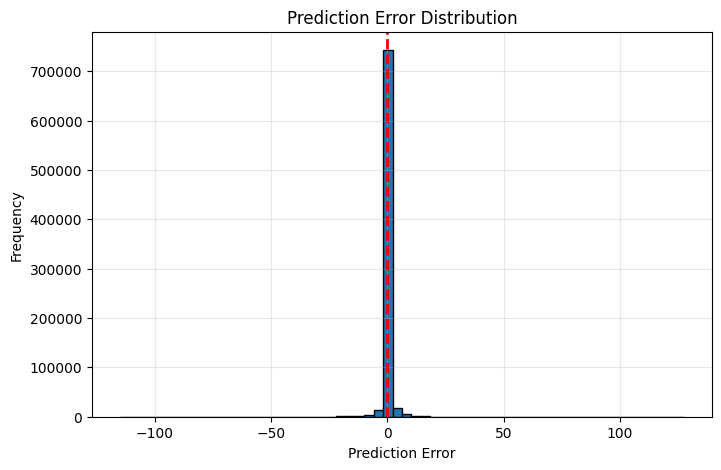

In [ ]:
# =====================================================
# PREDICTION ERROR HISTOGRAM
# =====================================================

errors = y_est - y_true

plt.figure(figsize=(8,5))

plt.hist(
    errors,
    bins=60,
    edgecolor="black"
)

plt.axvline(
    0,
    color="red",
    linestyle="--",
    linewidth=2
)

plt.title("Prediction Error Distribution")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()